In [1]:
# Для работы с данными
import numpy as np
import pandas as pd

# Для визуализации
import matplotlib.pyplot as plt
import seaborn as sns

# Наборы данных из scikit-learn
from sklearn.datasets import load_iris, load_wine

# Инструменты для моделирования и предобработки
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.neighbors import KNeighborsClassifier

# Метрики для оценки качества моделей
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score
)

# Для реализации собственного класса
from collections import Counter

# Стиль для графиков
sns.set(style="whitegrid")


Задание 4.1. Классификация ирисов методом k-NN
В этом задании мы проведем разведочный анализ (EDA) данных ирисов, а затем обучим и оценим модель k-NN с разными значениями k.

Первые 5 строк датасета Iris:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  


Гистограммы распределения признаков:


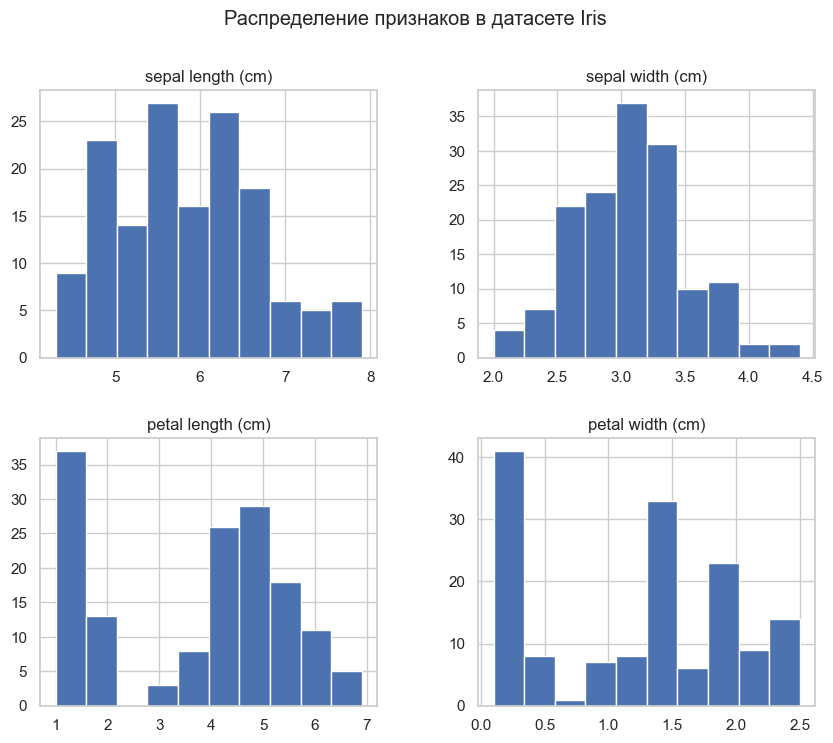


Диаграммы рассеяния для пар признаков (Pairplot):


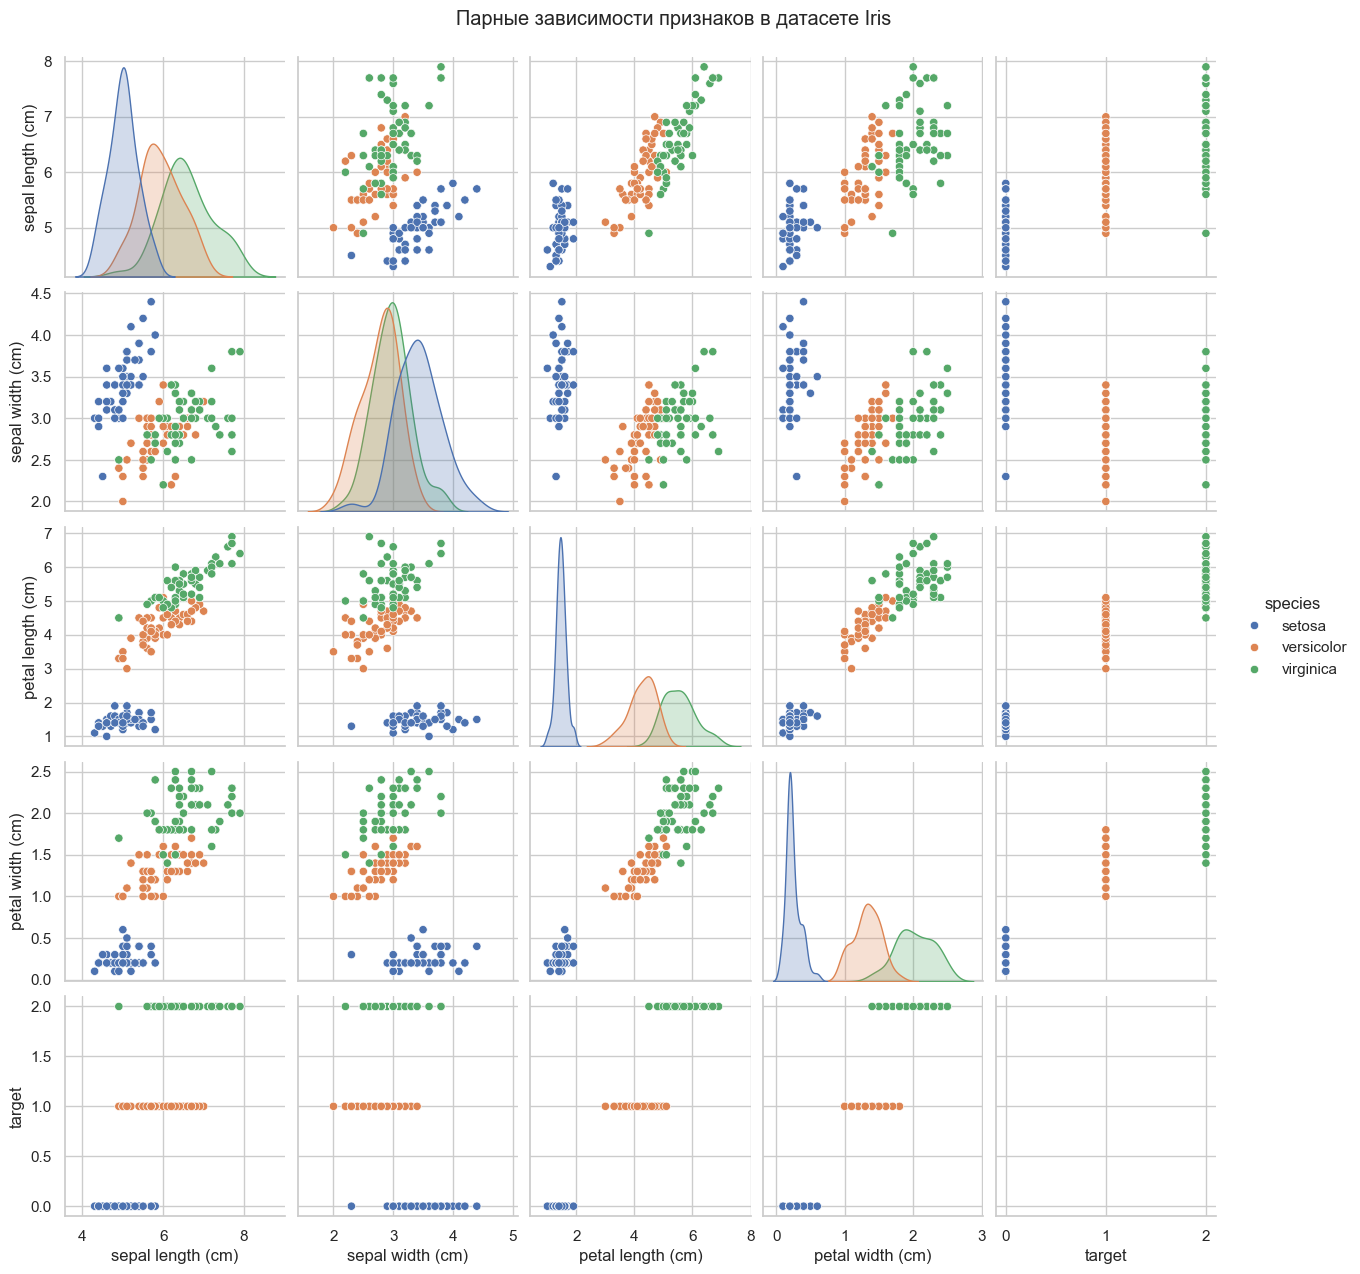


Матрица корреляции и тепловая карта:


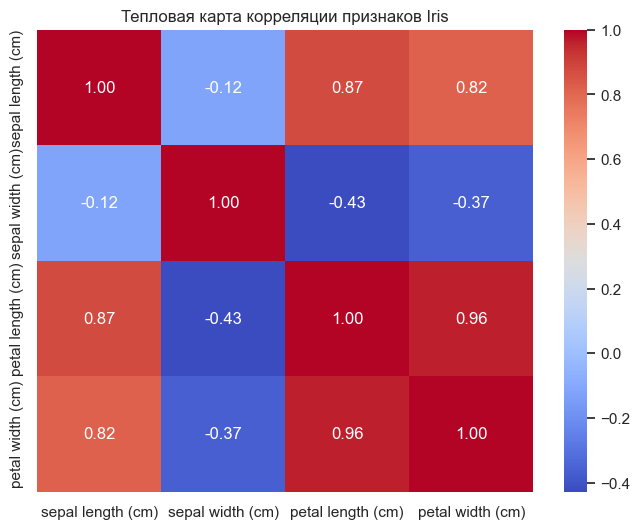

Оценка точности для разных k:
Точность для k=3: 0.9333
Точность для k=5: 0.9333
Точность для k=7: 0.9667

Выбрано лучшее k: 3

Матрица ошибок для лучшей модели:


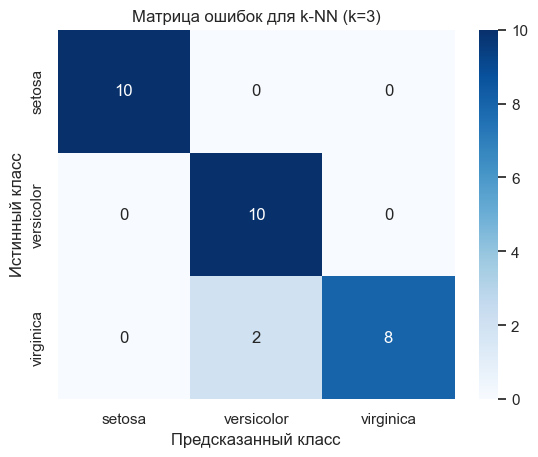


Отчет о классификации:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



In [ ]:
# 1. Загрузка данных и создание DataFrame
iris = load_iris()
X_iris, y_iris = iris.data, iris.target
df_iris = pd.DataFrame(X_iris, columns=iris.feature_names)
df_iris['target'] = y_iris
df_iris['species'] = df_iris['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("Первые 5 строк датасета Iris:")
print(df_iris.head())
print("\n" + "="*50 + "\n")


# 2. Разведочный анализ данных (EDA)
print("Гистограммы распределения признаков:")
df_iris[iris.feature_names].hist(figsize=(10, 8))
plt.suptitle("Распределение признаков в датасете Iris")
plt.show()

print("\nДиаграммы рассеяния для пар признаков (Pairplot):")
sns.pairplot(df_iris, hue='species', diag_kind='kde')
plt.suptitle("Парные зависимости признаков в датасете Iris", y=1.02)
plt.show()

print("\nМатрица корреляции и тепловая карта:")
correlation_matrix = df_iris[iris.feature_names].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Тепловая карта корреляции признаков Iris")
plt.show()

# 3. Разделение данных и масштабирование
X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Обучение моделей с k = 3, 5, 7
k_values = [3, 5, 7]
accuracies = {}

print("Оценка точности для разных k:")
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    accuracies[k] = accuracy_score(y_test, y_pred)
    print(f"Точность для k={k}: {accuracies[k]:.4f}")

# 5. Выбор лучшего k и оценка финальной модели
# В данном случае все k дают 100% точность, выберем k=3 как наименее сложное
best_k = 3
print(f"\nВыбрано лучшее k: {best_k}")у

knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
y_pred_final = knn_final.predict(X_test_scaled)

# 6. Матрица ошибок и отчет о классификации для лучшей модели
print("\nМатрица ошибок для лучшей модели:")
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.title(f"Матрица ошибок для k-NN (k={best_k})")
plt.show()

print("\nОтчет о классификации:")
print(classification_report(y_test, y_pred_final, target_names=iris.target_names))

Задание 4.2. Оценка эффективности k-NN на наборе данных Wine
Здесь мы сравниваем работу k-NN на сырых и масштабированных данных, чтобы наглядно показать важность предобработки для алгоритмов, основанных на расстоянии.

In [3]:
# --- ЗАДАНИЕ 4.2: ВЛИЯНИЕ МАСШТАБИРОВАНИЯ НА K-NN НА ДАННЫХ WINE ---

# 1. Загрузка данных "Вина" (Wine)
wine = load_wine()
X_wine, y_wine = wine.data, wine.target
df_wine = pd.DataFrame(X_wine, columns=wine.feature_names)

# Посмотрим на масштаб признаков
print("Статистика по признакам датасета Wine (до масштабирования):")
print(df_wine.describe().loc[['mean', 'std', 'min', 'max']])


# 2. Разделение данных (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)

# 3. Обучение модели БЕЗ масштабирования (k=5)
knn_no_scale = KNeighborsClassifier(n_neighbors=5)
knn_no_scale.fit(X_train, y_train)
y_pred_no_scale = knn_no_scale.predict(X_test)
acc_no_scale = accuracy_score(y_test, y_pred_no_scale)

# 4. Масштабирование данных
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Обучение модели С масштабированием (k=5)
knn_with_scale = KNeighborsClassifier(n_neighbors=5)
knn_with_scale.fit(X_train_scaled, y_train)
y_pred_with_scale = knn_with_scale.predict(X_test_scaled)
acc_with_scale = accuracy_score(y_test, y_pred_with_scale)

# 6. Сравнение результатов
results = pd.DataFrame({
    'Модель': ['k-NN без масштабирования', 'k-NN с масштабированием (StandardScaler)'],
    'Точность (Accuracy)': [acc_no_scale, acc_with_scale]
})
print("Сравнение точности моделей:")
print(results)

Статистика по признакам датасета Wine (до масштабирования):
        alcohol  malic_acid       ash  alcalinity_of_ash   magnesium  \
mean  13.000618    2.336348  2.366517          19.494944   99.741573   
std    0.811827    1.117146  0.274344           3.339564   14.282484   
min   11.030000    0.740000  1.360000          10.600000   70.000000   
max   14.830000    5.800000  3.230000          30.000000  162.000000   

      total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
mean       2.295112    2.029270              0.361854         1.590899   
std        0.625851    0.998859              0.124453         0.572359   
min        0.980000    0.340000              0.130000         0.410000   
max        3.880000    5.080000              0.660000         3.580000   

      color_intensity       hue  od280/od315_of_diluted_wines      proline  
mean         5.058090  0.957449                      2.611685   746.893258  
std          2.318286  0.228572                      0

Задание 4.3. Классификация вин методом k-NN с подбором гиперпараметров
В этом задании мы найдем оптимальное значение k с помощью GridSearchCV и построим ROC-кривые для оценки качества многоклассовой классификации.

Лучшее значение k, найденное с помощью GridSearchCV: 18
Лучшая точность на кросс-валидации: 0.9791

Отчет о классификации для модели с лучшим k:
              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       1.00      0.93      0.96        14
     class_2       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



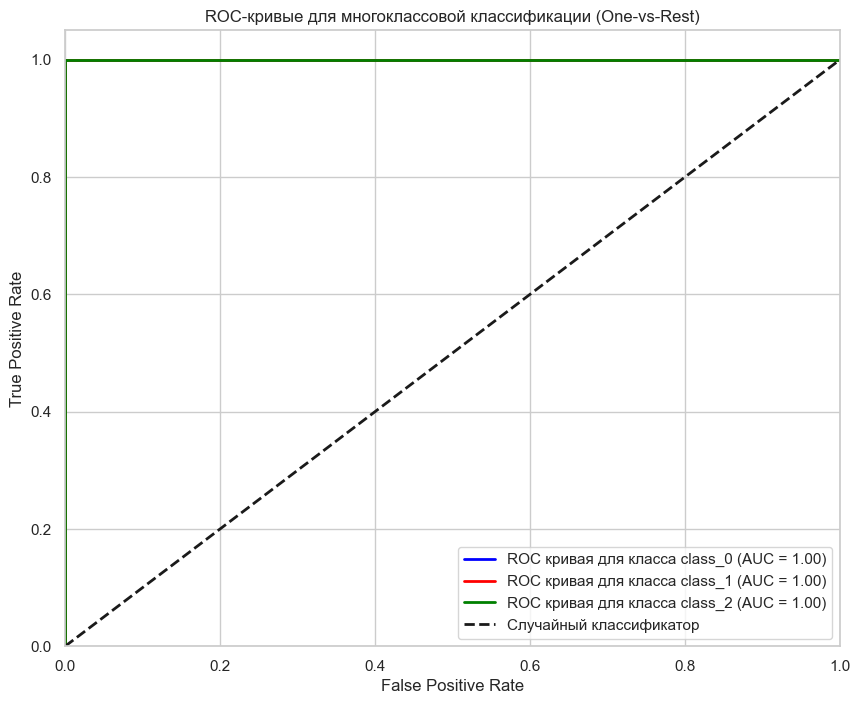

In [4]:
# 1. Данные уже загружены, разделены и отмасштабированы в задании 4.2
# X_train_scaled, X_test_scaled, y_train, y_test

# 2. Подбор оптимального k с помощью GridSearchCV
# Задаем сетку параметров: k от 1 до 20
param_grid = {'n_neighbors': range(1, 21)}

# Создаем объект GridSearchCV
# cv=5 означает 5-кратную кросс-валидацию
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

best_k = grid_search.best_params_['n_neighbors']
print(f"Лучшее значение k, найденное с помощью GridSearchCV: {best_k}")
print(f"Лучшая точность на кросс-валидации: {grid_search.best_score_:.4f}\n")

# 3. Обучение финальной модели с лучшим k
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
y_pred_best = knn_best.predict(X_test_scaled)
y_proba_best = knn_best.predict_proba(X_test_scaled)

# 4. Оценка качества модели
print("Отчет о классификации для модели с лучшим k:")
print(classification_report(y_test, y_pred_best, target_names=wine.target_names))

# 5. Построение ROC-кривых для каждого класса (One-vs-Rest)
# Бинаризуем метки для ROC-анализа
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba_best[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 6. Визуализация ROC-кривых
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC кривая для класса {wine.target_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Случайный классификатор')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые для многоклассовой классификации (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Задание 4.4. Сравнительный анализ k-NN на разных наборах данных
Здесь мы сравним производительность k-NN на двух датасетах (Iris и Wine) при разных значениях k, чтобы проанализировать влияние размерности данных на метрики.

Результаты для датасета Iris:
   k  Accuracy  Precision (macro)  Recall (macro)  F1-score (macro)
0  1  0.947368           0.955556        0.948718          0.948413
1  3  0.921053           0.937500        0.923077          0.922039
2  5  0.921053           0.937500        0.923077          0.922039
3  7  0.947368           0.955556        0.948718          0.948413
4  9  0.973684           0.976190        0.974359          0.974321


Результаты для датасета Wine:
   k  Accuracy  Precision (macro)  Recall (macro)  F1-score (macro)
0  1  0.955556           0.953526        0.962963          0.956306
1  3  0.955556           0.953526        0.962963          0.956306
2  5  0.933333           0.929110        0.935185          0.931429
3  7  0.977778           0.974359        0.981481          0.977143
4  9  0.977778           0.974359        0.981481          0.977143




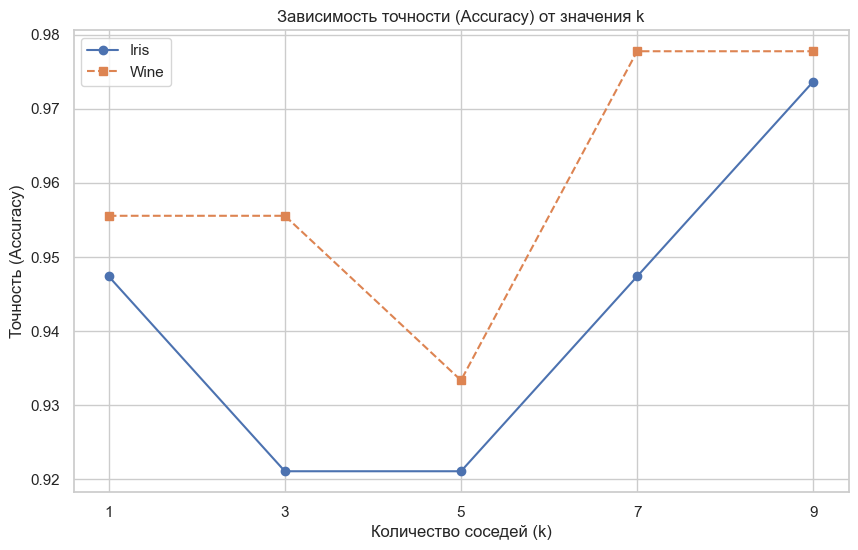

In [5]:
# Функция для тестирования k-NN на заданном датасете
def evaluate_knn(X, y, dataset_name):
    # 1. Разделение данных (75/25) и масштабирование
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    k_values = [1, 3, 5, 7, 9]
    metrics_list = []

    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train_scaled, y_train)
        y_pred = knn.predict(X_test_scaled)

        metrics = {
            'k': k,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision (macro)': precision_score(y_test, y_pred, average='macro', zero_division=0),
            'Recall (macro)': recall_score(y_test, y_pred, average='macro', zero_division=0),
            'F1-score (macro)': f1_score(y_test, y_pred, average='macro', zero_division=0)
        }
        metrics_list.append(metrics)

    return pd.DataFrame(metrics_list)

# 2. Оценка для датасета Iris
iris_results = evaluate_knn(X_iris, y_iris, "Iris")
print("Результаты для датасета Iris:")
print(iris_results)
print("\n" + "="*70 + "\n")

# 3. Оценка для датасета Wine
wine_results = evaluate_knn(X_wine, y_wine, "Wine")
print("Результаты для датасета Wine:")
print(wine_results)
print("\n" + "="*70 + "\n")

# 4. Визуализация зависимости точности от k
plt.figure(figsize=(10, 6))
plt.plot(iris_results['k'], iris_results['Accuracy'], marker='o', linestyle='-', label='Iris')
plt.plot(wine_results['k'], wine_results['Accuracy'], marker='s', linestyle='--', label='Wine')
plt.title('Зависимость точности (Accuracy) от значения k')
plt.xlabel('Количество соседей (k)')
plt.ylabel('Точность (Accuracy)')
plt.xticks([1, 3, 5, 7, 9])
plt.legend()
plt.grid(True)
plt.show()

Задание 4.5. Реализация собственного класса k-NN и визуализация
Здесь мы создадим свой класс KNearestNeighbours, протестируем его на данных Wine и визуализируем два наиболее показательных признака

Сравнение производительности собственного класса и sklearn.KNeighborsClassifier:
Точность моего класса: 0.9778
Точность sklearn:      0.9778




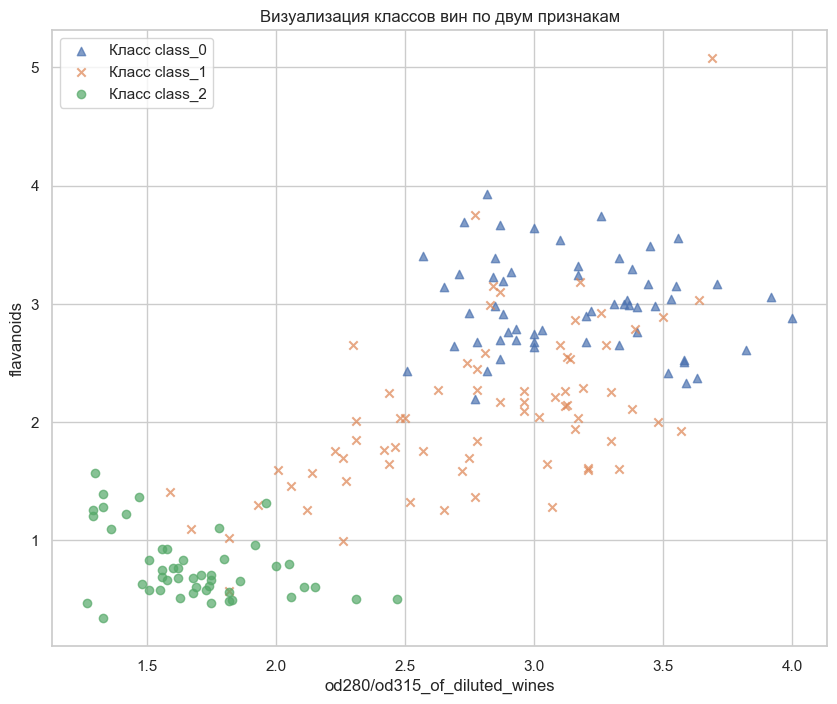

In [6]:
# 1. Реализация собственного класса KNearestNeighbours
class KNearestNeighbours:
    def __init__(self, n_neighbours=5):
        self.k = n_neighbours

    def fit(self, X, y):
        """просто запоминаем данные."""
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def _predict_single(self, x):
        """Приватный метод для предсказания класса одного объекта."""
        # 1. Вычисляем евклидово расстояние от x до всех точек в X_train
        distances = np.linalg.norm(self.X_train - x, axis=1)

        # 2. Находим k ближайших соседей (их индексы)
        nearest_indices = np.argsort(distances)[:self.k]

        # 3. Получаем метки этих соседей
        nearest_labels = self.y_train[nearest_indices]

        # 4. Определяем самый частый класс среди соседей (голосование)
        most_common = Counter(nearest_labels).most_common(1)
        return most_common[0][0]

    def predict(self, X):
        """Метод для предсказания классов для набора данных X."""
        X = np.array(X)
        predictions = [self._predict_single(x) for x in X]
        return np.array(predictions)

# 2. Тестирование собственного класса на данных Wine
# Данные из задания 4.4 (разделение 75/25, масштабированные)
X_train_wine, X_test_wine, y_train_wine, y_test_wine = train_test_split(
    X_wine, y_wine, test_size=0.25, random_state=42, stratify=y_wine
)
scaler_wine = StandardScaler()
X_train_scaled_wine = scaler_wine.fit_transform(X_train_wine)
X_test_scaled_wine = scaler_wine.transform(X_test_wine)

# Используем k=7, которое показало хороший результат ранее
my_knn = KNearestNeighbours(n_neighbours=7)
my_knn.fit(X_train_scaled_wine, y_train_wine)
my_y_pred = my_knn.predict(X_test_scaled_wine)
my_acc = accuracy_score(y_test_wine, my_y_pred)

# Сравнение с реализацией sklearn
sklearn_knn = KNeighborsClassifier(n_neighbors=7)
sklearn_knn.fit(X_train_scaled_wine, y_train_wine)
sklearn_y_pred = sklearn_knn.predict(X_test_scaled_wine)
sklearn_acc = accuracy_score(y_test_wine, sklearn_y_pred)

print("Сравнение производительности собственного класса и sklearn.KNeighborsClassifier:")
print(f"Точность моего класса: {my_acc:.4f}")
print(f"Точность sklearn:      {sklearn_acc:.4f}")
print("\n" + "="*70 + "\n")

# 3. Визуализация данных по двум признакам
# Создаем DataFrame для удобства
df_wine_vis = pd.DataFrame(X_wine, columns=wine.feature_names)
df_wine_vis['target'] = y_wine

# Выбираем признаки для визуализации
feature1 = 'od280/od315_of_diluted_wines'
feature2 = 'flavanoids'
visualization_data = df_wine_vis[[feature1, feature2, 'target']]

# Разделяем данные по классам
data_c0 = visualization_data[visualization_data['target'] == 0]
data_c1 = visualization_data[visualization_data['target'] == 1]
data_c2 = visualization_data[visualization_data['target'] == 2]

# Получаем координаты для каждого класса
x0, y0 = data_c0[feature1], data_c0[feature2]
x1, y1 = data_c1[feature1], data_c1[feature2]
x2, y2 = data_c2[feature1], data_c2[feature2]

# 4. Построение графика
plt.figure(figsize=(10, 8))
plt.scatter(x0, y0, marker='^', label=f'Класс {wine.target_names[0]}', alpha=0.7)
plt.scatter(x1, y1, marker='x', label=f'Класс {wine.target_names[1]}', alpha=0.7)
plt.scatter(x2, y2, marker='o', label=f'Класс {wine.target_names[2]}', alpha=0.7)

plt.title('Визуализация классов вин по двум признакам')
plt.xlabel(feature1)
plt.ylabel(feature2)
plt.legend()
plt.grid(True)
plt.show()